# Dividend Prediction Model Using LSTM
### Predicting Future Dividends Based on Historical Data and Stock Prices

This project aims to predict stock dividends using a Long Short-Term Memory (LSTM) neural network. 
The model is trained on historical data, including stock dividends and prices, to forecast future dividends.

The notebook includes data preprocessing, feature engineering, model training, and evaluation.


In [1]:
# Importing necessary libraries
# - pandas and numpy for data manipulation and numerical operations.
# - matplotlib for data visualization.
# - sklearn for data preprocessing and model evaluation.
# - tensorflow.keras for building the LSTM model.
# - yfinance for downloading financial data.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD
import yfinance as yf
import warnings

warnings.filterwarnings('ignore', category = UserWarning)

### Loading and Filtering out Relevant Data

I will be using the yfinance API to get historical dividends payment and stock prices. The dataframe provided by 
yfinance includes the open, high, low, close, volume, dividends, and stock splits of the specified stock. For the 
prediction of dividends, we only need the dividends and the stock prices. First, I filter out the dividends with
the period set to 'max' to extract as much data yfinance provides.

PS. To train and test the prediction model, I used historical data of Microsoft since it has reasonably lengthy 
data and regularly pays dividends to investors.

In [2]:
def request_data(symbol):
    dat = yf.Ticker(symbol)
    dat= dat.history(period="max", interval="1d")
    dat.reset_index(inplace=True)
    dat['Date'] = pd.to_datetime(dat['Date'])
    return dat

print(yf.__version__)

0.2.66


In [3]:
def filter_dividend(data):
    filtered_df = data[data['Dividends'] > 0]
    filtered_df = filtered_df[['Date', 'Dividends']]
    filtered_df['Date'] = pd.to_datetime(filtered_df['Date'])
    filtered_df['Date'] = filtered_df['Date'].dt.to_period('M').astype(str)
    filtered_df.set_index('Date', inplace=True)

    return filtered_df

### Adding the stock prices

We will also use stock prices as one of the two features to train the LSTM model. To ensure appropriate shape of 
input data while taking into consideration the changes in stock prices that occurs every single day, I decided to 
use the average of all close prices from 1 month prior to the date each dividend is paid to one day before that.
This way, the stock prices used to train the model has the same number of rows as the number of historical 
dividends, while considering all the stock prices during the period when dividends were not paid.

In [4]:
def add_stock_prices(dividend_data, stock_data):
    dividend_data = dividend_data.reset_index()
    stock_data['Date'] = pd.to_datetime(stock_data['Date']).dt.tz_localize(None)
    dividend_data['Date'] = pd.to_datetime(dividend_data['Date']).dt.tz_localize(None)
    
    # Create a list to store results
    average_prices = []
    
    # Loop through each dividend payment date
    for div_date in dividend_data['Date']:
        # Calculate the start and end of the 3-month period
        start_date = (div_date - pd.DateOffset(months=1)).replace(day=1)
        end_date = div_date - pd.Timedelta(days=1)  # Day before the dividend month
    
        # Filter stock data for the 3-month period
        filtered_stock = stock_data[(stock_data['Date'] >= start_date) & (stock_data['Date'] <= end_date)]
    
        # Calculate the average close price
        avg_close_price = filtered_stock['Close'].mean()
        average_prices.append(avg_close_price)
    
    # Add the average prices as a new column to the dividend DataFrame
    dividend_data['Avg_Close_Prev_1_Month'] = average_prices
    return dividend_data

In [5]:
tickers = ["SPY", "QQQ", "VTI", "IWM", "DIA", "EFA", "EEM", "VNQ", "XLK", "XLF", "SCHD"]
frames = []
for t in tickers:
    div = request_data(t)
    div = filter_dividend(div)

    stk = request_data(t)
    df  = add_stock_prices(div, stk)   # <-- your existing function that computes Avg_Close_Prev_1_Month
    df["Ticker"] = t
    frames.append(df)

train_data = (pd.concat(frames, ignore_index=True)
                .sort_values(["Ticker", "Date"])
                .reset_index(drop=True))

# ensure your two feature cols exist for all rows you’ll use
train_data = train_data.dropna(subset=["Dividends", "Avg_Close_Prev_1_Month"])
print(train_data.head())

        Date  Dividends  Avg_Close_Prev_1_Month Ticker
0 1998-04-01      0.340               48.752214    DIA
1 1998-05-01      0.090               50.623341    DIA
2 1998-06-01      0.190               50.933627    DIA
3 1998-08-01      0.197               51.150307    DIA
4 1998-09-01      0.109               47.681565    DIA


The plot below shows a comprehensive visualization of the dataframe that will be used to train and test the model. (Only shows SCHD)

          Date  Dividends  Avg_Close_Prev_1_Month Ticker
607 2011-12-01   0.040667                5.427609   SCHD
608 2012-03-01   0.046000                5.851565   SCHD
609 2012-06-01   0.068667                5.892692   SCHD
610 2012-09-01   0.069333                6.246389   SCHD
611 2012-12-01   0.086000                6.187944   SCHD


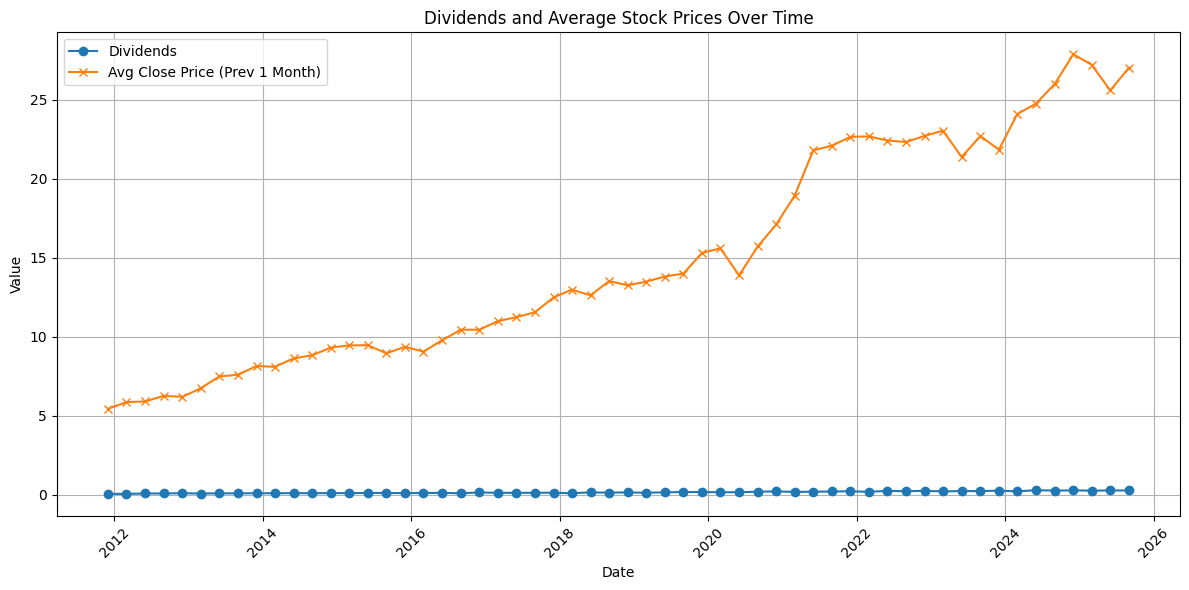

In [6]:
plt.figure(figsize=(12, 6))

plot_sample = train_data[train_data['Ticker'] == 'SCHD']
print(plot_sample.head())

# Plot dividends as a line
plt.plot(plot_sample['Date'], plot_sample['Dividends'], label='Dividends', marker='o')

# Plot average close prices as a line
plt.plot(plot_sample['Date'], plot_sample['Avg_Close_Prev_1_Month'], label='Avg Close Price (Prev 1 Month)', marker='x')

# Add labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Dividends and Average Stock Prices Over Time')
plt.legend()
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

Preprocessing the data into sequential data of length 12, and splitting into the train and test input; train and test target : 



In [7]:
scaler = MinMaxScaler()
train_data[['Dividends', 'Avg_Close_Prev_1_Month']] = scaler.fit_transform(train_data[['Dividends', 'Avg_Close_Prev_1_Month']])

In [8]:
X, y = [], []

for t, sub in train_data.groupby("Ticker"):
    sub = sub.sort_values("Date")
    for i in range(len(sub) - 12):
        X.append(sub.iloc[i:i+12][["Dividends", "Avg_Close_Prev_1_Month"]].values)
        y.append(sub.iloc[i+12]["Dividends"])

X = np.array(X); y = np.array(y)
print(X.shape, y.shape)

(1031, 12, 2) (1031,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

### Configuring the LSTM model

The layers of the LSTM model is shown in the table below. 
First, I used the SGD optimizer and changed to the Adam optimizer to compare the prediction accuracy of the two 
optimizers.

At the last epoch, the SGD optimizer finished training with the mean squared error (loss) of 0.0051, while the Adam optimzer ended with the MSE of 0.000022116. 

With the MSE (after training) of the model that used the Adam optimizer being significantly smaller than the model that used the SGD optimizer (performance increased by 99.5%), I concluded that the Adam optimizer is more suitable for this model.


In [10]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

model.add(LSTM(units=50, activation='relu', return_sequences = True))
model.add(LSTM(units=50, activation='relu'))
model.add(Dense(units = 1))
model.compile(optimizer = SGD(learning_rate = 0.001), loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 12, 50)              │          10,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,851 (120.51 KB)

 Trainable params: 30,851 (120.51 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(X_train, y_train, epochs = 50, batch_size = 32)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0822   
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0681 
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0593 
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0550 
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0449 
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0468 
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0455 
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0426 
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0379 
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0377 
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0345 
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0333 
Epoch 13/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0299 
Epoch 14/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0342 
Epoch 15/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0346 
Ep

In [12]:
model.compile(optimizer = Adam(learning_rate = 0.001), loss='mean_squared_error')
model.fit(X_train, y_train, epochs = 50, batch_size = 32)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0256
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083 
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0077 
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0071 
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0086 
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0077 
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074 
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0068 
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076 
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0071 
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0071 
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0075 
Epoch 13/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064 
Epoch 14/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0067 
Epoch 15/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0054 
Epoch

### Evaluation of the model

The difference between the training and the testing loss seem to be relatively small, indicating that the model is the overfitting significantly. 
Both losses are very small, indicating that the model's predictions are very close to actual values. Since the mean squared error was used as the loss function, these loss values represent squared differences, so the actual magnitudes of the errors will be even smaller.

In [13]:
train_loss = model.evaluate(X_train, y_train, verbose = 0)
test_loss = model.evaluate(X_test, y_test, verbose = 0)
print(f'Training Loss: {train_loss}, Testing Loss: {test_loss}')

Training Loss: 0.005021080374717712, Testing Loss: 0.0006614855956286192


In [14]:
dividend_scaler = MinMaxScaler()

train_data['Dividends'] = dividend_scaler.fit_transform(train_data[['Dividends']])

y_test_reshaped = y_test.reshape(-1, 1)

predicted_scaled = model.predict(X_test)

predicted = dividend_scaler.inverse_transform(predicted_scaled)
actual = dividend_scaler.inverse_transform(y_test_reshaped)

print("Predicted Dividends:")
print(predicted.flatten())
print("Actual Dividends:")
print(actual.flatten())

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step 
Predicted Dividends:
[0.22076227 0.21281293 0.22933437 0.23872618 0.26284137 0.24417481
 0.25319567 0.26652113 0.27563465 0.2710893  0.27626437 0.2927585
 0.3022095  0.30402845 0.30572864 0.31618893 0.326745   0.3289274
 0.33743536 0.3498975  0.3651652  0.36053577 0.37020546 0.37510982
 0.3869277  0.38536203 0.3944488  0.40560153 0.41032103 0.4195008
 0.41168377 0.42952245 0.44453475 0.43134153 0.44688234 0.44990858
 0.46161053 0.45931455 0.4688965  0.48230353 0.49940583 0.49925467
 0.51620066 0.04243468 0.04339403 0.04436791 0.04571266 0.04651823
 0.04766726 0.04861673 0.05060646 0.05064025 0.05316962 0.05511764
 0.05825042 0.05839451 0.06475831 0.07015115 0.07233796 0.07138049
 0.07541438 0.078278   0.08054487 0.07995962 0.082336   0.0848815
 0.08854557 0.0873024  0.09071771 0.09157249 0.09494499 0.09058079
 0.08953242 0.08868003 0.09145498 0.07362917 0.07516177 0.07537313
 0.06801702 0.05550129 0.05012893 0.04520566 0.04084472 0.03327002
 0.031

### Prediction of another stock with the trained model.

Using the trained model, I forecasted the next five dividend payments for JEPI (JPMorgan Equity Premium Income ETF), a widely regarded ETF known for its attractive dividend yield. This prediction aims to provide valuable insights for investors who prioritize high dividend payouts in their investment strategies.

In [15]:
def prepare_for_prediction(symbol):
    test_data = request_data(symbol)
    test_data = filter_dividend(test_data)
    test_stock_data = request_data(symbol)
    test_data = add_stock_prices(test_data, test_stock_data)
    return test_data

def predict_dividends(test_data, sequence_length, num_predictions):
    last_sequence = test_data.iloc[-sequence_length:][['Dividends', 'Avg_Close_Prev_1_Month']].values
    last_sequence_scaled = scaler.transform(last_sequence)
    current_input = last_sequence_scaled.reshape(1, sequence_length, 2)
    
    future_dividends = []
    for _ in range(num_predictions):
        # Predict the next dividend
        next_dividend_scaled = model.predict(current_input)  # Output: (1, 1)
        next_dividend = scaler.inverse_transform([[next_dividend_scaled[0, 0], 0]])[0, 0]  # Rescale to original scale
    
        # Append the prediction to the results
        future_dividends.append(next_dividend)
    
        # Update the input sequence
        # Remove the oldest timestep and add the predicted dividend with the most recent avg_close
        next_avg_close = train_data.iloc[-1]['Avg_Close_Prev_1_Month']  # Use the most recent avg_close from train_data
        next_timestep = [next_dividend_scaled[0, 0], scaler.transform([[0, next_avg_close]])[0, 1]]  # Scale avg_close
    
        # Append the new timestep and remove the oldest
        current_input = np.append(current_input[:, 1:, :], [[next_timestep]], axis=1)  # Update input
    
    # Print predictions
    print("Predicted Future Dividends:")
    print(future_dividends)
    return future_dividends

In [21]:
sequence_length = 12
num_predictions = 5
symbol = "SCHD"

to_be_predicted = prepare_for_prediction(symbol)
future_dividends = predict_dividends(to_be_predicted, sequence_length, num_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Future Dividends:
[0.2620971130728722, 0.2538192780762911, 0.2625657287836075, 0.263177979439497, 0.27038331833481793]


[0.2620971130728722, 0.2538192780762911, 0.2625657287836075, 0.263177979439497, 0.27038331833481793]


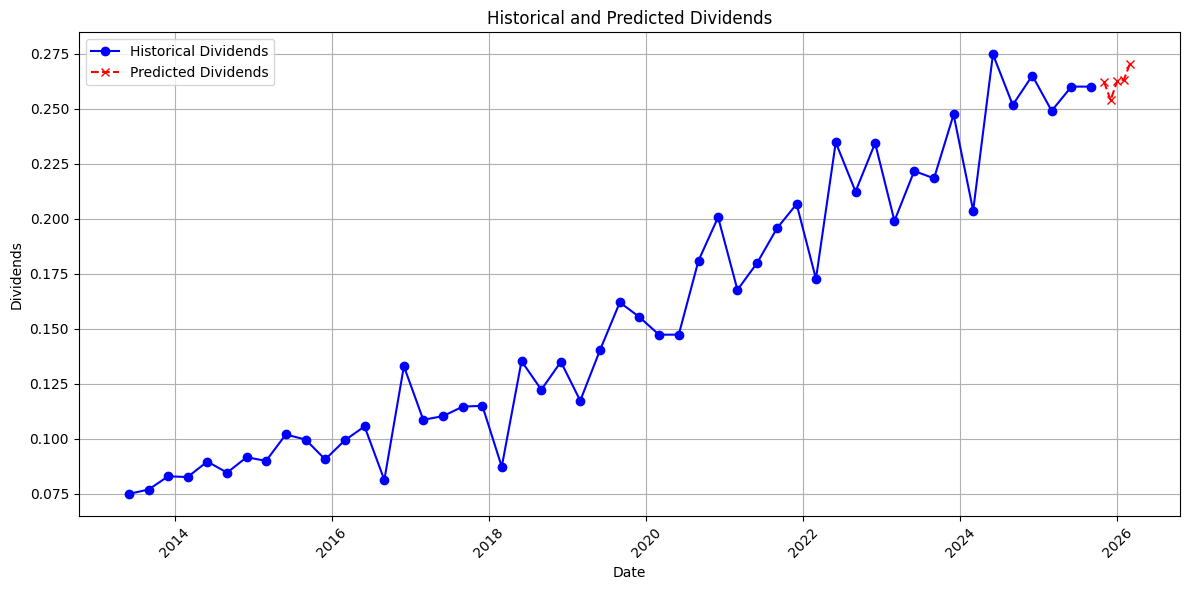

In [22]:
print(future_dividends)

historical_dividends = to_be_predicted['Dividends'].values[-50:]  # Last 50 dividends
historical_dates = to_be_predicted['Date'].values[-50:]  # Corresponding dates

# Generate dates for predicted dividends
# Predicted dividends correspond to the next 5 months after the last date in `to_be_trained`
predicted_dividends = np.array(future_dividends)
predicted_dates = pd.date_range(start=to_be_predicted['Date'].iloc[-1], periods=len(future_dividends) + 1, freq='ME')[1:]

# Plot historical dividends
plt.figure(figsize=(12, 6))
plt.plot(historical_dates, historical_dividends, label='Historical Dividends', color='blue', marker='o')

# Plot predicted dividends
plt.plot(predicted_dates, predicted_dividends, label='Predicted Dividends', color='red', linestyle='--', marker='x')

# Add labels, legend, and title
plt.xlabel('Date')
plt.ylabel('Dividends')
plt.title('Historical and Predicted Dividends')
plt.legend()
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

In [20]:
import joblib
import os

os.makedirs("model_artifacts", exist_ok=True)

# save trained model as .h5
model.save("model_artifacts/model.h5")

# save scaler
joblib.dump(scaler, "model_artifacts/scaler.joblib")

print("Artifacts saved:")
print(" - model_artifacts/dividend_lstm_multi_ticker.h5")
print(" - model_artifacts/scaler.joblib")

Artifacts saved:
 - artifacts/dividend_lstm_multi_ticker.h5
 - artifacts/scaler.joblib


### Acknowledgments
This notebook was inspired by the concepts and methodology outlined in the following article:
- [Dividend Payout Prediction Model](https://medium.com/@ruslan.s/dividend-payout-prediction-model-8302fb226d) by Ruslan S.
